<a href="https://colab.research.google.com/github/it-ces/PUBLIC-AI/blob/main/Probability/Simlab/poisson_panel_lgd_ead_monetary_loss(ai_page).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Iván Trujillo Abella
# ivantrujillo1229@gmail.com

In [ ]:
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
url_train = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel_default_lgd_ead_modelling.csv"
url_test= "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel(test)_default_lgd_ead_modelling.csv"

In [ ]:
panel_train = pd.read_csv(url_train)

panel_train['ead_at_default'] = np.where(panel_train['new_default'],
                                         panel_train['outstanding_balance'],0.0)
panel_train['loss_on_default'] = panel_train['ead_at_default'] * panel_train['lgd']
panel_train['loss_on_default'] = panel_train['loss_on_default']/1000000


panel_test = pd.read_csv(url_test)
panel_test['loss_on_default'] = panel_test['loss_on_default']/1000000

In [ ]:
panel_train.columns

Index(['id_credit', 'cohort', 'delivery_date', 'execution_date', 'age_months',
       'term_months', 'original_amount', 'outstanding_balance',
       'days_past_due', 'default_state', 'new_default', 'at_risk', 'lgd',
       'ead_at_default', 'loss_on_default'],
      dtype='object')

In [ ]:
historical_loss = panel_train.groupby('execution_date')[['loss_on_default']].sum()
display(historical_loss)
mean_loss = historical_loss['loss_on_default'].mean()

,loss_on_default
execution_date,
2023-01-31,3.316825
2023-02-28,28.232425
2023-03-31,22.353731
2023-04-30,50.597685
2023-05-31,51.231115
2023-06-30,51.747900
2023-07-31,35.120125
2023-08-31,37.689960
2023-09-30,84.532717


In [ ]:
mean_loss # perdida promedio mensual

np.float64(53.14054230758949)

In [ ]:
results = panel_test.groupby(by=['execution_date'])[['loss_on_default']].sum()
results

,loss_on_default
execution_date,
2028-01-31,55.347953
2028-02-29,88.444434
2028-03-31,75.875779
2028-04-30,57.689566
2028-05-31,55.839205
2028-06-30,65.872270
2028-07-31,66.618243
2028-08-31,56.991399
2028-09-30,46.402188


In [ ]:
LAMBDA = panel_train.groupby(by=['execution_date'])['new_default'].sum().values.mean()

In [ ]:
LAMBDA

np.float64(21.65)

In [ ]:
severity = panel_train[panel_train['new_default']==1]['loss_on_default'].mean()
severity

np.float64(2.454528513052632)

In [ ]:
LAMBDA  * severity

np.float64(53.140542307589484)

In [ ]:
LAMBDA

np.float64(21.65)

In [ ]:
poisson.ppf(0.99, LAMBDA) * severity

np.float64(80.99944093073687)

In [ ]:
results['historical'] = mean_loss
results['expected_poisson'] = LAMBDA  * severity
results['sceneraio99_poisson'] = poisson.ppf(0.99, LAMBDA) * severity
results['sceneraio1_poisson'] = poisson.ppf(0.01, LAMBDA) * severity

In [ ]:
results

,loss_on_default,historical,expected_poisson,sceneraio99_poisson,sceneraio1_poisson
execution_date,,,,,
2028-01-31,55.347953,53.140542,53.140542,80.999441,29.454342
2028-02-29,88.444434,53.140542,53.140542,80.999441,29.454342
2028-03-31,75.875779,53.140542,53.140542,80.999441,29.454342
2028-04-30,57.689566,53.140542,53.140542,80.999441,29.454342
2028-05-31,55.839205,53.140542,53.140542,80.999441,29.454342
2028-06-30,65.872270,53.140542,53.140542,80.999441,29.454342
2028-07-31,66.618243,53.140542,53.140542,80.999441,29.454342
2028-08-31,56.991399,53.140542,53.140542,80.999441,29.454342
2028-09-30,46.402188,53.140542,53.140542,80.999441,29.454342


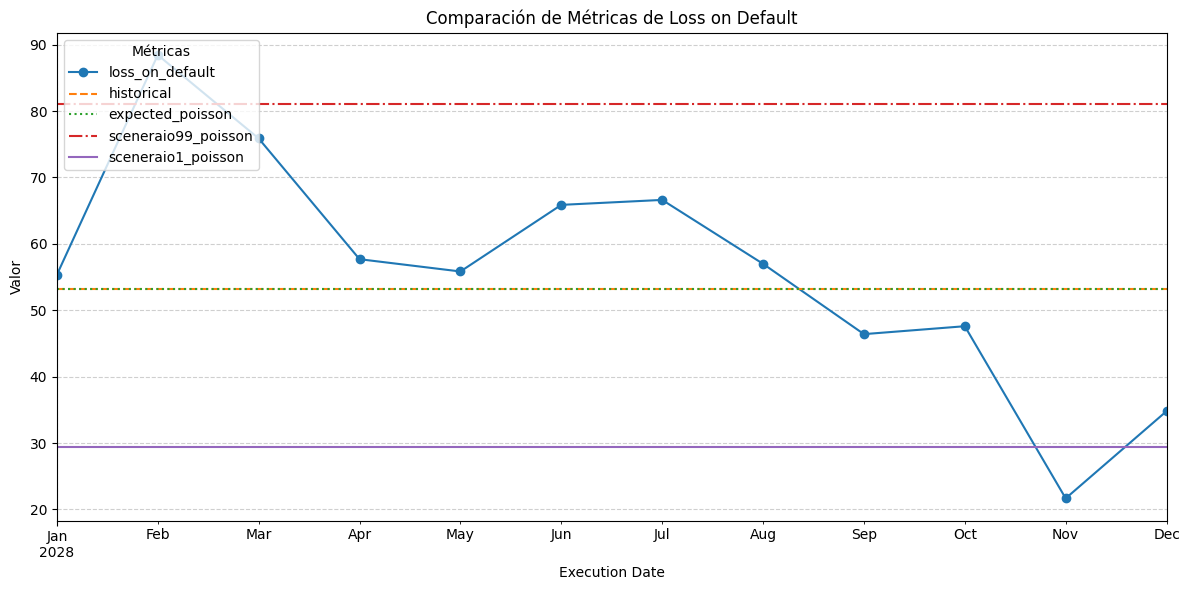

In [ ]:
import matplotlib.pyplot as plt

# Asegurar que el índice sea tipo datetime para que el eje X se vea limpio
results.index = pd.to_datetime(results.index)

# Graficar las 4 columnas directamente desde Pandas
ax = results.plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.'], # Estilos de línea opcionales para mayor claridad
    title="Comparación de Métricas de Loss on Default"
)

# Personalizar etiquetas y leyenda
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Ajustemos... la exposición..
panel_train['new_default'].value_counts(normalize=True)

,proportion
new_default,
0,0.993908
1,0.006092


In [ ]:
panel_train

,id_credit,cohort,delivery_date,execution_date,age_months,term_months,original_amount,outstanding_balance,days_past_due,default_state,new_default,at_risk,lgd,ead_at_default,loss_on_default
0,1,2023-01,2023-01-01,2023-01-31,0,14,9.411862e+06,9.411862e+06,0,0,0,1,0.474948,0.0,0.0
1,1,2023-01,2023-01-01,2023-02-28,1,14,9.411862e+06,8.739586e+06,0,0,0,1,0.474948,0.0,0.0
2,1,2023-01,2023-01-01,2023-03-31,2,14,9.411862e+06,8.067310e+06,0,0,0,1,0.474948,0.0,0.0
3,1,2023-01,2023-01-01,2023-04-30,3,14,9.411862e+06,7.395034e+06,0,0,0,1,0.474948,0.0,0.0
4,1,2023-01,2023-01-01,2023-05-31,4,14,9.411862e+06,6.722759e+06,0,0,0,1,0.474948,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213209,16268,2027-12,2027-12-31,2027-12-31,0,14,1.609272e+07,1.609272e+07,0,0,0,1,0.291342,0.0,0.0
213210,16269,2027-12,2027-12-31,2027-12-31,0,14,3.000000e+07,3.000000e+07,0,0,0,1,0.425676,0.0,0.0
213211,16270,2027-12,2027-12-31,2027-12-31,0,15,7.372265e+06,7.372265e+06,0,0,0,1,0.429045,0.0,0.0
213212,16271,2027-12,2027-12-31,2027-12-31,0,18,1.084091e+07,1.084091e+07,0,0,0,1,0.220547,0.0,0.0


In [ ]:
N_t = panel_train.groupby('execution_date')['at_risk'].sum() # riesgo de su primer default

In [ ]:
D_t = panel_train.groupby('execution_date')['new_default'].sum()

In [ ]:
p_hat = (panel_train['new_default'].sum()/panel_train['at_risk'].sum())

In [ ]:
p_hat

np.float64(0.0063466781320539005)

In [ ]:
results_adj_size = (panel_test.groupby('execution_date')['at_risk'].sum().mul(p_hat).rename('lambda').reset_index())
results_adj_size['poisson_exposure_p05'] = poisson.ppf(0.05,results_adj_size['lambda'])
results_adj_size['poisson_exposure_p95'] = poisson.ppf(0.95,results_adj_size['lambda'])

In [ ]:
results_adj_size['mean_loss']  = mean_loss

In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss
0,2028-01-31,25.932527,18.0,35.0,53.140542
1,2028-02-29,27.157436,19.0,36.0,53.140542
2,2028-03-31,27.671517,19.0,37.0,53.140542
3,2028-04-30,27.963464,20.0,37.0,53.140542
4,2028-05-31,27.792104,19.0,37.0,53.140542
5,2028-06-30,27.252636,19.0,36.0,53.140542
6,2028-07-31,26.421221,18.0,35.0,53.140542
7,2028-08-31,25.450179,17.0,34.0,53.140542
8,2028-09-30,23.977750,16.0,32.0,53.140542
9,2028-10-31,22.454547,15.0,31.0,53.140542


In [ ]:
results_adj_size['scenario_95'] = results_adj_size['poisson_exposure_p95'] * severity
results_adj_size['scenario_5'] = results_adj_size['poisson_exposure_p05'] * severity
results_adj_size['poisson_loss'] = results_adj_size['lambda'] * severity
results_adj_size['loss_on_default'] = results['loss_on_default'].values

In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


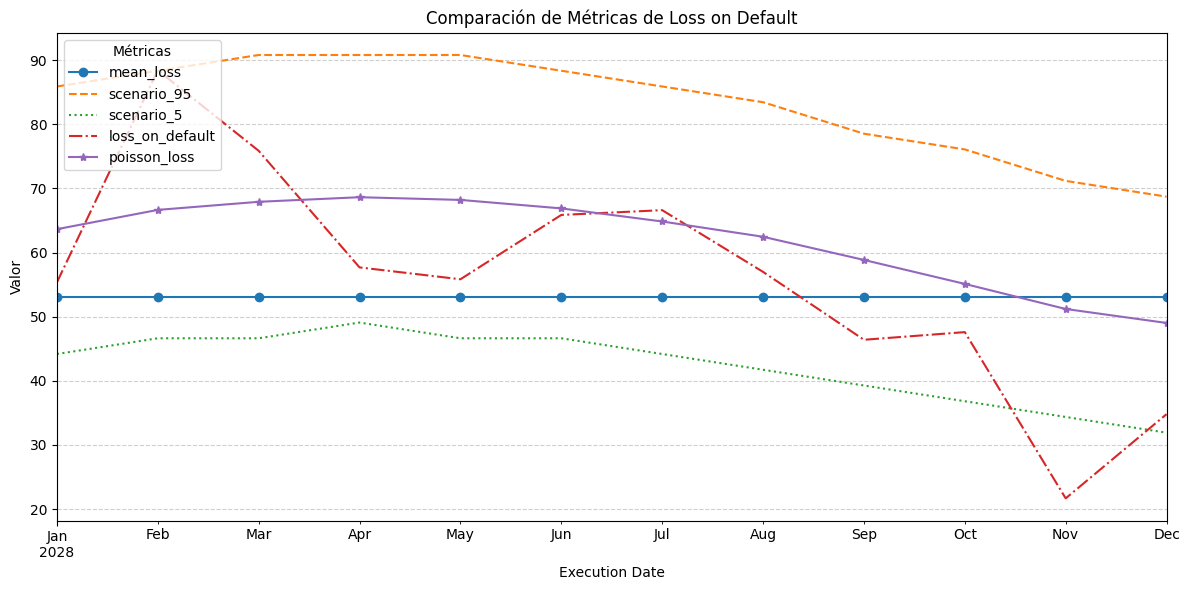

In [ ]:
results_adj_size.index = pd.to_datetime(results_adj_size['execution_date'])
ax = results_adj_size[['mean_loss', 'scenario_95', 'scenario_5', 'loss_on_default', 'poisson_loss']].plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.','-*'],
    title="Comparación de Métricas de Loss on Default"
)
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print((results_adj_size['loss_on_default'] - results_adj_size['mean_loss']).abs().sum()) # pérdida del histórico
print((results_adj_size['loss_on_default'] - results_adj_size['scenario_95']).abs().sum()) # pérdida de peor scenario
print((results_adj_size['loss_on_default'] - results_adj_size['poisson_loss']).abs().sum())# pérdida de poisson ajustada

159.64712190626614
326.0075125415811
133.3628645903873


In [ ]:
(133.3628645903873  - 159.64712190626614)  / 159.64712190626614 * 100

-16.463971916331296

In [ ]:
severity_data = panel_train.loc[
    panel_train["new_default"] == 1,
    "loss_on_default"
]

In [ ]:
severity_data.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,loss_on_default
count,1299.000000
mean,2.454529
std,2.097975
min,0.082005
1%,0.147636
5%,0.286485
25%,0.946757
50%,1.886178
75%,3.299630
95%,6.671645


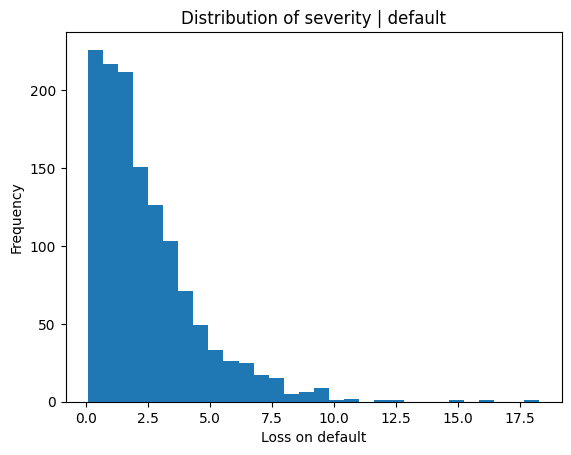

In [ ]:
plt.hist(severity_data, bins=30)
plt.xlabel("Loss on default")
plt.ylabel("Frequency")
plt.title("Distribution of severity | default")
plt.show()

cada Default genera una pérdida aletoria $X$ por lo que la pérdida agregada es

\begin{equation}
S = \sum_{i=1}^{N} X_{i}
\end{equation}

# Boostrap empírico


In [ ]:
losses_array = []
trials  = 100000
for _ in range(trials):
  n_defaults = np.random.poisson(LAMBDA)
  losses = np.random.choice(severity_data,size=n_defaults,replace=True)
  total_loss = losses.sum()
  losses_array.append(total_loss)
np.array(losses_array).mean()

np.float64(53.13479293424823)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm



In [ ]:
monthly_train = panel_train.groupby("execution_date").agg(defaults=("new_default", "sum"), at_risk=("at_risk", "sum"),
                                            actual_loss=("loss_on_default", "sum")).sort_index()
monthly_test = panel_test.groupby("execution_date").agg(defaults=("new_default", "sum"), at_risk=("at_risk", "sum"),
                                            actual_loss=("loss_on_default", "sum")).sort_index()

In [ ]:
monthly_test

,defaults,at_risk,actual_loss
execution_date,,,
2028-01-31,26,4086,55.347953
2028-02-29,29,4279,88.444434
2028-03-31,32,4360,75.875779
2028-04-30,27,4406,57.689566
2028-05-31,24,4379,55.839205
2028-06-30,31,4294,65.872270
2028-07-31,29,4163,66.618243
2028-08-31,23,4010,56.991399
2028-09-30,26,3778,46.402188


In [ ]:
monthly_train

,defaults,at_risk,actual_loss
execution_date,,,
2023-01-31,1,300,3.316825
2023-02-28,4,716,28.232425
2023-03-31,6,1180,22.353731
2023-04-30,9,1642,50.597685
2023-05-31,13,2164,51.231115
2023-06-30,11,2661,51.747900
2023-07-31,13,3001,35.120125
2023-08-31,14,3239,37.689960
2023-09-30,27,3428,84.532717


In [ ]:
risk_train = panel_train.loc[panel_train["at_risk"]==1].copy()
risk_train["arrears"] = 100 * (risk_train["days_past_due"]>0) # podrían ser 30 días?
risk_train["young"] = 100 * (risk_train["age_months"]<3)
risk_train["potential_loss"] = (risk_train["outstanding_balance"]* risk_train["lgd"] / 1_000_000)
characteristics_train = risk_train.groupby("execution_date").agg(mean_age=("age_months","mean"),
                                          arrears_pct=("arrears","mean"),
                                          young_pct=("young","mean"),
                                          avg_potential_loss=("potential_loss","mean"))


risk_test = panel_test.loc[panel_test["at_risk"]==1].copy()
risk_test["arrears"] = 100 * (risk_test["days_past_due"]>0) # podrían ser 30 días?
risk_test["young"] = 100 * (risk_test["age_months"]<3)
risk_test["potential_loss"] = (risk_test["outstanding_balance"]* risk_test["lgd"] / 1_000_000)
characteristics_test = risk_test.groupby("execution_date").agg(mean_age=("age_months","mean"),
                                          arrears_pct=("arrears","mean"),
                                          young_pct=("young","mean"),
                                          avg_potential_loss=("potential_loss","mean"))


monthly_train  = monthly_train.join(characteristics_train,how="inner")
monthly_test  = monthly_test.join(characteristics_test,how="inner")



In [ ]:
monthly_train

,defaults,at_risk,actual_loss,mean_age,arrears_pct,young_pct,avg_potential_loss
execution_date,,,,,,,
2023-01-31,1,300,3.316825,0.000000,6.333333,100.000000,4.405645
2023-02-28,4,716,28.232425,0.417598,4.329609,100.000000,4.305051
2023-03-31,6,1180,22.353731,0.855085,5.762712,100.000000,4.142202
2023-04-30,9,1642,50.597685,1.328258,5.542022,81.912302,4.014592
2023-05-31,13,2164,51.231115,1.757856,6.192237,67.329020,3.869470
2023-06-30,11,2661,51.747900,2.227734,5.261180,56.444946,3.734609
2023-07-31,13,3001,35.120125,2.850050,4.965012,46.151283,3.525210
2023-08-31,14,3239,37.689960,3.547082,4.260574,34.238963,3.296313
2023-09-30,27,3428,84.532717,4.278880,5.630105,23.395566,3.081799


In [ ]:

all_monthly = pd.concat([monthly_train.assign(sample="train") , monthly_test.assign(sample="test")]).sort_index()
for column in ["mean_age", "arrears_pct", "young_pct"]:
    all_monthly[column + "_lag1"] = all_monthly[column].shift(1)


features = ["mean_age_lag1","arrears_pct_lag1","young_pct_lag1"]


# Volvemos a separar train y test
monthly_train_model= (all_monthly[all_monthly["sample"] == "train"].dropna(subset=features).copy())
monthly_test_model= (all_monthly[all_monthly["sample"] == "test"].dropna(subset=features).copy())



"""
REGRESIÓN POISSON: ESTIMAR LAMBDA
 log(lambda_t)
 = log(at_risk_t)
 + beta0
 + beta1 * edad promedio previa
 + beta2 * porcentaje mora previo
 + beta3 * porcentaje jóvenes previo
# El offset controla por el tamaño de la cartera.
"""


X_train = sm.add_constant(monthly_train_model[features],has_constant="add")

X_test = sm.add_constant(monthly_test_model[features], has_constant="add")


model_poisson_dynamic = sm.GLM(monthly_train_model["defaults"], X_train, family=sm.families.Poisson(),
                               offset=np.log(monthly_train_model["at_risk"]),missing="raise",).fit()


results_dynamic = monthly_test_model[["defaults","at_risk","actual_loss","avg_potential_loss"]].copy()


results_dynamic["lambda_regression"] = model_poisson_dynamic.predict(X_test,offset=np.log(monthly_test_model["at_risk"]))


results_dynamic["expected_dynamic"] = (results_dynamic["lambda_regression"]*results_dynamic["avg_potential_loss"])


In [ ]:
results_dynamic

,defaults,at_risk,actual_loss,avg_potential_loss,lambda_regression,expected_dynamic
execution_date,,,,,,
2028-01-31,26,4086,55.347953,2.350426,26.462471,62.198092
2028-02-29,29,4279,88.444434,2.333427,29.462519,68.748633
2028-03-31,32,4360,75.875779,2.277122,29.181652,66.450173
2028-04-30,27,4406,57.689566,2.273856,27.056843,61.523370
2028-05-31,24,4379,55.839205,2.275048,27.426369,62.396311
2028-06-30,31,4294,65.872270,2.275005,25.950795,59.038192
2028-07-31,29,4163,66.618243,2.269603,27.014957,61.313219
2028-08-31,23,4010,56.991399,2.291151,25.356706,58.096034
2028-09-30,26,3778,46.402188,2.271086,23.969976,54.437867


In [ ]:
monthly_test

,defaults,at_risk,actual_loss,mean_age,arrears_pct,young_pct,avg_potential_loss
execution_date,,,,,,,
2028-01-31,26,4086,55.347953,7.255751,5.261870,12.310328,2.350426
2028-02-29,29,4279,88.444434,7.276934,5.375088,17.527460,2.333427
2028-03-31,32,4360,75.875779,7.425229,4.793578,20.756881,2.277122
2028-04-30,27,4406,57.689566,7.447798,5.197458,23.422606,2.273856
2028-05-31,24,4379,55.839205,7.543503,4.704270,21.283398,2.275048
2028-06-30,31,4294,65.872270,7.555892,5.379599,20.726595,2.275005
2028-07-31,29,4163,66.618243,7.624309,4.972376,18.520298,2.269603
2028-08-31,23,4010,56.991399,7.597257,4.937656,17.705736,2.291151
2028-09-30,26,3778,46.402188,7.647962,5.134992,15.616728,2.271086


In [ ]:
historical_mean = (monthly_train["actual_loss"].mean())
severity_fixed = panel_train.loc[panel_train["new_default"].eq(1),"loss_on_default"].mean()
p_hat = (monthly_train["defaults"].sum()/monthly_train["at_risk"].sum())
results_dynamic["historical"] = historical_mean
results_dynamic["exposure_fixed"] = (results_dynamic["at_risk"]*p_hat*severity_fixed)
results_dynamic["regression_fixed"] = (results_dynamic["lambda_regression"]*severity_fixed)


# Here we go!

decimos que $N_{t} \sim Poisson(\lambda_{t})$, la perdida monetaria $X_{i}$ we can uses the empirical distribution of losses.

then if observed $N_{t}$ defaults then the total lost in month is

\begin{equation}
L_{t} = \sum_{i=1}^{N_{t}} X_{i}
\end{equation}

that is **compound poisson** using monte carlo, we are simulate several scenarios for a particular month.

by properties:

\begin{equation}
E[L_{t}] = E[N_{t}] E[X]
\end{equation}

for poisson we know the expected value..

\begin{equation}
E[L_{t}] = \lambda_{t} E[X]
\end{equation}

now:

\begin{equation}
VAR(L_{t}) = \lambda_{t} E[X^{2}]
\end{equation}

that is equal to:

\begin{equation}
VAR(L_{t})   = \lambda_{t} [ var(X) + (E[X])^{2}]
\end{equation}


the following simulation:

In [ ]:
results_dynamic

,defaults,at_risk,actual_loss,avg_potential_loss,lambda_regression,expected_dynamic,historical,exposure_fixed,regression_fixed
execution_date,,,,,,,,,
2028-01-31,26,4086,55.347953,2.350426,26.462471,62.198092,53.140542,63.652127,64.952888
2028-02-29,29,4279,88.444434,2.333427,29.462519,68.748633,53.140542,66.658700,72.316592
2028-03-31,32,4360,75.875779,2.277122,29.181652,66.450173,53.140542,67.920527,71.627196
2028-04-30,27,4406,57.689566,2.273856,27.056843,61.523370,53.140542,68.637119,66.411793
2028-05-31,24,4379,55.839205,2.275048,27.426369,62.396311,53.140542,68.216511,67.318806
2028-06-30,31,4294,65.872270,2.275005,25.950795,59.038192,53.140542,66.892372,63.696967
2028-07-31,29,4163,66.618243,2.269603,27.014957,61.313219,53.140542,64.851640,66.308981
2028-08-31,23,4010,56.991399,2.291151,25.356706,58.096034,53.140542,62.468191,62.238757
2028-09-30,26,3778,46.402188,2.271086,23.969976,54.437867,53.140542,58.854071,58.834990


In [ ]:
severities_train = panel_train.loc[panel_train["new_default"].eq(1),"loss_on_default"].dropna().to_numpy()

In [ ]:
trials = 10000
rng = np.random.default_rng(20261005)
bands = []
for month, row in results_dynamic.iterrows():
    lambda_t = row["lambda_regression"]
    Losses = []
    for _ in range(trials):
        n_defaults = rng.poisson(lambda_t)
        if n_defaults == 0:
          total_loss = 0
        else:
            losses = rng.choice(severities_train, size=n_defaults,replace=True)
            total_loss = (losses.sum())
        Losses.append(total_loss)
    simulations = np.array(Losses)
    bands.append({"month":month,"p05":np.quantile(simulations,0.05),"p50":np.quantile(simulations,0.50),"p95":np.quantile(simulations,0.95),"simulated_mean":simulations.mean()})
bands = (pd.DataFrame(bands).set_index("month"))

results_dynamic[["p05","p50","p95","simulated_mean"]] = bands[["p05","p50","p95","simulated_mean"]]


In [ ]:
results_dynamic

,defaults,at_risk,actual_loss,avg_potential_loss,lambda_regression,expected_dynamic,historical,exposure_fixed,regression_fixed,p05,p50,p95,simulated_mean
execution_date,,,,,,,,,,,,,
2028-01-31,26,4086,55.347953,2.350426,26.462471,62.198092,53.140542,63.652127,64.952888,39.738952,63.799302,93.857569,64.922018
2028-02-29,29,4279,88.444434,2.333427,29.462519,68.748633,53.140542,66.658700,72.316592,45.610628,71.027142,103.158711,72.232557
2028-03-31,32,4360,75.875779,2.277122,29.181652,66.450173,53.140542,67.920527,71.627196,44.826521,70.842942,101.814295,71.675107
2028-04-30,27,4406,57.689566,2.273856,27.056843,61.523370,53.140542,68.637119,66.411793,40.256903,65.415382,96.262326,66.481887
2028-05-31,24,4379,55.839205,2.275048,27.426369,62.396311,53.140542,68.216511,67.318806,41.161487,66.287550,96.397648,67.303240
2028-06-30,31,4294,65.872270,2.275005,25.950795,59.038192,53.140542,66.892372,63.696967,38.302789,62.766898,92.154395,63.531625
2028-07-31,29,4163,66.618243,2.269603,27.014957,61.313219,53.140542,64.851640,66.308981,40.292189,65.196383,94.894177,66.177970
2028-08-31,23,4010,56.991399,2.291151,25.356706,58.096034,53.140542,62.468191,62.238757,37.651404,60.948862,90.631257,62.192223
2028-09-30,26,3778,46.402188,2.271086,23.969976,54.437867,53.140542,58.854071,58.834990,34.415672,57.875716,86.816272,58.825234


In [ ]:
results_dynamic["error_dynamic"] = (results_dynamic["actual_loss"] - results_dynamic["expected_dynamic"])
results_dynamic["absolute_error_dynamic"] = (results_dynamic["error_dynamic"].abs())
results_dynamic["inside_band_fixed"] = (results_dynamic["actual_loss"].between(results_dynamic["p05"],results_dynamic["p95"]))

In [ ]:
# ==========================================================
# COMPOUND POISSON PARA EL MODELO DINÁMICO
#
# Queremos que:
#
# E[L_t] = lambda_t * avg_potential_loss_t
#
# Las severidades históricas de train nos dan la FORMA
# de la distribución, pero el nivel monetario lo determina
# avg_potential_loss_t de cada mes.
# ==========================================================

severities_train = (panel_train.loc[panel_train["new_default"].eq(1),"loss_on_default"].dropna().to_numpy())
severity_shape = (severities_train/ severities_train.mean())
trials = 10_000
rng = np.random.default_rng(20261005)
bands_dynamic = []
for month, row in results_dynamic.iterrows():
    lambda_t = row["lambda_regression"]
    avg_loss_t = row["avg_potential_loss"]
    simulated_losses = []
    for _ in range(trials):
        n_defaults = rng.poisson(lambda_t)
        if n_defaults == 0:
            total_loss = 0.0
        else:
            severity_multiplier = rng.choice(severity_shape,size=n_defaults,replace=True)
            simulated_severity = (severity_multiplier* avg_loss_t)
            total_loss = simulated_severity.sum()
        simulated_losses.append(total_loss)
    simulated_losses = np.array(simulated_losses)

    bands_dynamic.append({
        "month": month,
        "p05_dynamic": np.quantile(simulated_losses, 0.05),
        "p50_dynamic": np.quantile(simulated_losses, 0.50),
        "p95_dynamic": np.quantile(simulated_losses, 0.95),
        "simulated_mean_dynamic": simulated_losses.mean()
    })


bands_dynamic = (
    pd.DataFrame(bands_dynamic)
    .set_index("month")
)


results_dynamic[
    [
        "p05_dynamic",
        "p50_dynamic",
        "p95_dynamic",
        "simulated_mean_dynamic"
    ]
] = bands_dynamic[
    [
        "p05_dynamic",
        "p50_dynamic",
        "p95_dynamic",
        "simulated_mean_dynamic"
    ]
]

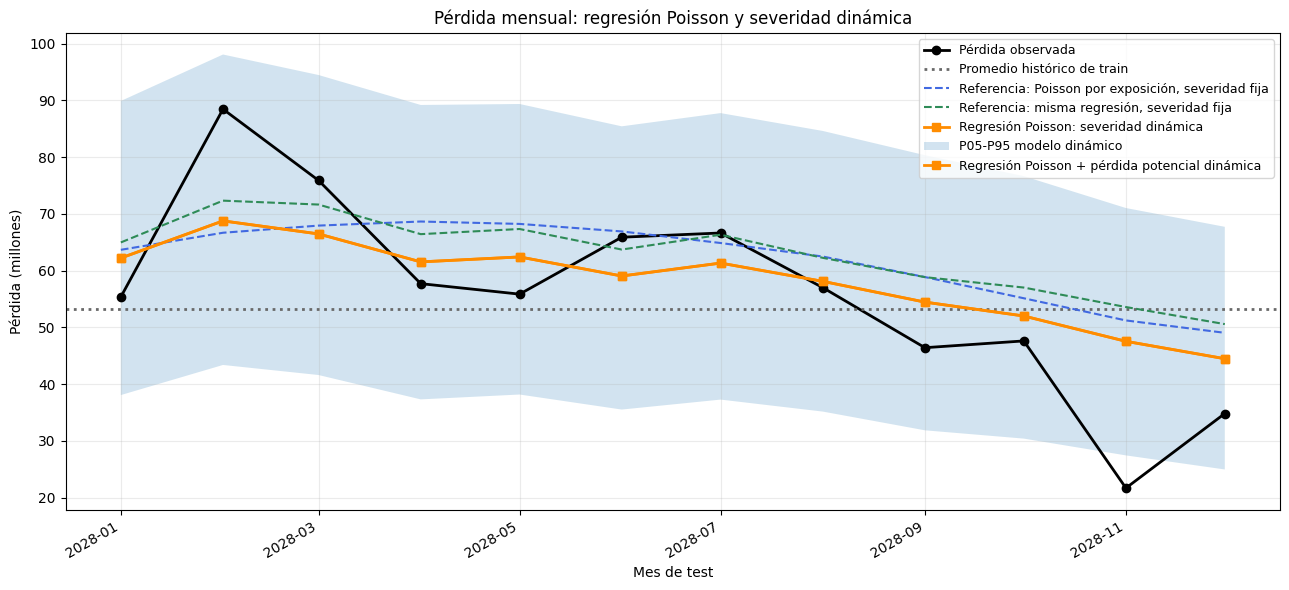

In [ ]:
# ==========================================================
# 8. MÉTRICAS DE ERROR
#
# MAE:
# error absoluto promedio mensual
#
# RMSE:
# penaliza errores grandes
#
# SAE:
# suma de errores absolutos
#
# WAPE:
# error absoluto total como porcentaje de la pérdida real total
#
# BIAS:
# error promedio con signo
# positivo = sobreestima
# negativo = subestima
# ==========================================================

actual = results_dynamic["actual_loss"]

metric_rows = []

for label, column in [
    ("Promedio histórico", "historical"),
    ("Poisson por exposición, severidad fija", "exposure_fixed"),
    ("Regresión Poisson, severidad fija", "regression_fixed"),
    ("Regresión Poisson + EAD×LGD promedio", "expected_dynamic"),
]:

    pred = results_dynamic[column]

    # Error para métricas absolutas
    error = actual - pred

    # Bias definido como Pronóstico - Real
    bias = (pred - actual).mean()

    # WAPE
    wape = (
        error.abs().sum()
        / actual.abs().sum()
        * 100
    )

    metric_rows.append({
        "Modelo": label,
        "MAE (millones)": error.abs().mean(),
        "RMSE (millones)": np.sqrt(np.mean(error**2)),
        "SAE (millones)": error.abs().sum(),
        "WAPE (%)": wape,
        "BIAS (millones)": bias
    })

metrics_dynamic = (
    pd.DataFrame(metric_rows)
    .set_index("Modelo")
)

metrics_dynamic


# ==========================================================
# 14. GRÁFICA
#
# Conservamos:
#
# - Banda P05-P95
# - Pérdida observada
# - Promedio histórico
# - Poisson por exposición
# - Regresión con severidad fija
# - Regresión con severidad dinámica
# ==========================================================
dates = pd.PeriodIndex(results_dynamic.index, freq="M").to_timestamp()

fig, ax = plt.subplots(
    figsize=(13, 6)
)


# Pérdida observada
ax.plot(

    dates,

    actual,

    "-o",

    color="black",

    linewidth=2,

    label="Pérdida observada",

)




# Promedio histórico
ax.axhline(

    historical_mean,

    color="dimgray",

    linestyle=":",

    linewidth=2,

    label="Promedio histórico de train",

)


# Poisson sencillo por exposición
ax.plot(

    dates,

    results_dynamic[
        "exposure_fixed"
    ],

    "--",

    color="royalblue",

    label=(
        "Referencia: Poisson por exposición, "
        "severidad fija"
    ),

)



# Regresión Poisson + severidad histórica fija
ax.plot(

    dates,

    results_dynamic[
        "regression_fixed"
    ],

    "--",

    color="seagreen",

    label=(
        "Referencia: misma regresión, "
        "severidad fija"
    ),

)


# Modelo principal
ax.plot(

    dates,

    results_dynamic[
        "expected_dynamic"
    ],

    "-s",

    color="darkorange",

    linewidth=2,

    label=(
        "Regresión Poisson: "
        "severidad dinámica"
    ),

)


ax.set(

    title=(
        "Pérdida mensual: "
        "regresión Poisson y severidad dinámica"
    ),

    xlabel="Mes de test",

    ylabel="Pérdida (millones)",

)


ax.fill_between(
    dates,
    results_dynamic["p05_dynamic"],
    results_dynamic["p95_dynamic"],
    alpha=0.20,
    label="P05-P95 modelo dinámico"
)

ax.plot(
    dates,
    results_dynamic["expected_dynamic"],
    "-s",
    color="darkorange",
    linewidth=2,
    label="Regresión Poisson + pérdida potencial dinámica"
)


ax.grid(
    alpha=0.25
)

ax.legend(
    fontsize=9
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()



In [ ]:
metrics_dynamic

,MAE (millones),RMSE (millones),SAE (millones),WAPE (%),BIAS (millones)
Modelo,,,,,
Promedio histórico,13.303927,17.218123,159.647122,23.716482,-2.955158
"Poisson por exposición, severidad fija",11.113572,13.540991,133.362865,19.811807,5.862307
"Regresión Poisson, severidad fija",10.617314,13.289738,127.407771,18.927144,6.807149
Regresión Poisson + EAD×LGD promedio,8.962624,11.192498,107.551484,15.977381,2.085872


# WAPE
how much is my error?
# BIAS
under or over estimation of losses?



#Weighted Absolute Percentage Error


# remeber regression fixed
$\lambda_{t}$ with the mean sevarity calculated in train.

In [ ]:
results_dynamic

,defaults,at_risk,actual_loss,avg_potential_loss,lambda_regression,expected_dynamic,historical,exposure_fixed,regression_fixed,p05,p50,p95,simulated_mean,error_dynamic,absolute_error_dynamic,inside_band_fixed,p05_dynamic,p50_dynamic,p95_dynamic,simulated_mean_dynamic
execution_date,,,,,,,,,,,,,,,,,,,,
2028-01-31,26,4086,55.347953,2.350426,26.462471,62.198092,53.140542,63.652127,64.952888,39.738952,63.799302,93.857569,64.922018,-6.850138,6.850138,True,38.053535,61.093432,89.876860,62.168530
2028-02-29,29,4279,88.444434,2.333427,29.462519,68.748633,53.140542,66.658700,72.316592,45.610628,71.027142,103.158711,72.232557,19.695801,19.695801,True,43.360289,67.522802,98.069063,68.668745
2028-03-31,32,4360,75.875779,2.277122,29.181652,66.450173,53.140542,67.920527,71.627196,44.826521,70.842942,101.814295,71.675107,9.425606,9.425606,True,41.586579,65.722603,94.455429,66.494621
2028-04-30,27,4406,57.689566,2.273856,27.056843,61.523370,53.140542,68.637119,66.411793,40.256903,65.415382,96.262326,66.481887,-3.833804,3.833804,True,37.293682,60.600302,89.176671,61.588304
2028-05-31,24,4379,55.839205,2.275048,27.426369,62.396311,53.140542,68.216511,67.318806,41.161487,66.287550,96.397648,67.303240,-6.557106,6.557106,True,38.151671,61.440463,89.348846,62.381883
2028-06-30,31,4294,65.872270,2.275005,25.950795,59.038192,53.140542,66.892372,63.696967,38.302789,62.766898,92.154395,63.531625,6.834078,6.834078,True,35.501335,58.176148,85.414253,58.884943
2028-07-31,29,4163,66.618243,2.269603,27.014957,61.313219,53.140542,64.851640,66.308981,40.292189,65.196383,94.894177,66.177970,5.305024,5.305024,True,37.256549,60.284444,87.744786,61.192078
2028-08-31,23,4010,56.991399,2.291151,25.356706,58.096034,53.140542,62.468191,62.238757,37.651404,60.948862,90.631257,62.192223,-1.104635,1.104635,True,35.145259,56.891997,84.598678,58.052597
2028-09-30,26,3778,46.402188,2.271086,23.969976,54.437867,53.140542,58.854071,58.834990,34.415672,57.875716,86.816272,58.825234,-8.035679,8.035679,True,31.843564,53.550286,80.327925,54.428840
